# 5. Respiration & RSA (Principles: vagal brake, cardiorespiratory coupling)

1. PAPERS: [Sensing Systems for Respiration Monitoring:
A Technical Systematic Review](https://github.com/roeh-health/lamina/blob/general_wesad_analysis/papers/sensingSystemsForRespirationMonitoringTechnicalSystematicReview.pdf)

In [28]:
import os
import sys

import numpy as np
import pandas as pd
import neurokit2 as nk

import matplotlib.pyplot as plt

from IPython.display import display

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../../signal'))

from data_processing import DataProcessing

In [2]:
respiration_frequency_sampling_rate = 700

## Load Data

In [3]:
data_path = "../../../data/WESAD/all_subjects/chest.csv"
df = DataProcessing.load_chest_df(base_dir=notebook_dir, file_type='.csv', path_to_file=data_path)
df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


## Get Specific Subject + Health Measure of Interest

In [4]:
## Option 1: Get s_id from .get_per_subject_dict()
s_id = 'S7'

per_subject_dfs, s_df = DataProcessing.get_data_per_subject(df, s_id)


### Option 2: Get s_id from per_subject_dfs
# s_df = per_subject_dfs[s_id]

### Option 3: Get s_id from per_subject_dfs
# s_id = 'None'

# per_subject_dfs = DataProcessing.get_per_subject_dict(df, s_id)
# print(per_subject_dfs)

# s3_id = 'S3'
# s3_df = DataProcessing.get_specific_subject_df(per_subject_dfs, s3_id)

In [5]:
s_df

,index,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,22626800,1.0696,-0.0140,1.4612,-0.019226,-0.048843,12.506866,33.993530,1.832581,S7,0
1,22626801,1.0654,-0.0102,1.4222,-0.016937,-0.007004,12.468719,33.932680,1.835632,S7,0
2,22626802,1.0654,0.0042,1.3202,-0.016159,0.071777,12.506866,33.970703,1.856995,S7,0
3,22626803,1.0666,0.0202,1.1464,-0.012405,0.088486,12.506485,34.008760,1.829529,S7,0
4,22626804,1.0602,0.0310,0.9192,-0.020325,0.090271,12.504959,33.887085,1.817322,S7,0
...,...,...,...,...,...,...,...,...,...,...,...
3666595,26293395,0.8586,-0.0958,-0.0390,0.156418,-0.036942,13.085556,34.917084,0.813293,S7,0
3666596,26293396,0.8526,-0.1026,-0.0430,0.115723,0.098831,13.089371,34.935608,0.816345,S7,0
3666597,26293397,0.8466,-0.1082,-0.0574,0.086380,0.199768,13.090134,34.943300,0.804138,S7,0
3666598,26293398,0.8422,-0.1138,-0.0814,0.139938,0.227646,13.081360,34.940247,0.834656,S7,0


In [6]:
health_measure_name = 'Resp'

In [7]:
resp_df = DataProcessing.get_specific_health_measure_df(s_df, health_measure_name)
resp_df

,Resp
0,1.832581
1,1.835632
2,1.856995
3,1.829529
4,1.817322
...,...
3666595,0.813293
3666596,0.816345
3666597,0.804138
3666598,0.834656


## Create Time Component

In [8]:
DataProcessing.create_time_df(resp_df, respiration_frequency_sampling_rate)
# resp_df.set_index(["Seconds"])

,Resp,Milliseconds,Seconds,Time
0,1.832581,0.00,0.00,0 days 00:00:00
1,1.835632,1.43,0.00,0 days 00:00:00
2,1.856995,2.86,0.00,0 days 00:00:00
3,1.829529,4.29,0.00,0 days 00:00:00
4,1.817322,5.71,0.01,0 days 00:00:00.010000
...,...,...,...,...
3666595,0.813293,5237992.86,5237.99,0 days 01:27:17.990000
3666596,0.816345,5237994.29,5237.99,0 days 01:27:17.990000
3666597,0.804138,5237995.71,5238.00,0 days 01:27:18
3666598,0.834656,5237997.14,5238.00,0 days 01:27:18


In [9]:
one_minute = 60
filt_one_minute = resp_df['Seconds'] <= one_minute
filt_one_minute

0           True
1           True
2           True
3           True
4           True
           ...  
3666595    False
3666596    False
3666597    False
3666598    False
3666599    False
Name: Seconds, Length: 3666600, dtype: bool

In [10]:
m_minutes = 3
M_seconds = one_minute * m_minutes
M_minutes_df = resp_df['Seconds'] <= M_seconds
M_minutes_df

0           True
1           True
2           True
3           True
4           True
           ...  
3666595    False
3666596    False
3666597    False
3666598    False
3666599    False
Name: Seconds, Length: 3666600, dtype: bool

## Clean Data

In [11]:
clean_col_name = "Cleaned Resp"
resp_df[clean_col_name] = nk.rsp_clean(resp_df[health_measure_name])
resp_df

,Resp,Milliseconds,Seconds,Time,Cleaned Resp
0,1.832581,0.00,0.00,0 days 00:00:00,0.826737
1,1.835632,1.43,0.00,0 days 00:00:00,0.823691
2,1.856995,2.86,0.00,0 days 00:00:00,0.820619
3,1.829529,4.29,0.00,0 days 00:00:00,0.817520
4,1.817322,5.71,0.01,0 days 00:00:00.010000,0.814394
...,...,...,...,...,...
3666595,0.813293,5237992.86,5237.99,0 days 01:27:17.990000,-0.001080
3666596,0.816345,5237994.29,5237.99,0 days 01:27:17.990000,-0.000927
3666597,0.804138,5237995.71,5238.00,0 days 01:27:18,-0.000788
3666598,0.834656,5237997.14,5238.00,0 days 01:27:18,-0.000663


### Visualize Cleaned Data

+ [x] Need to properly align time and plots

<Axes: title={'center': 'N Minutes = M Seconds'}, xlabel='Seconds'>

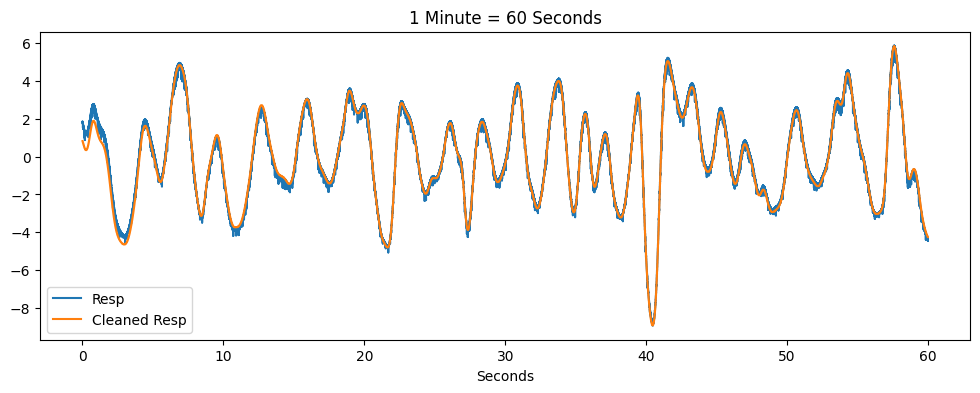

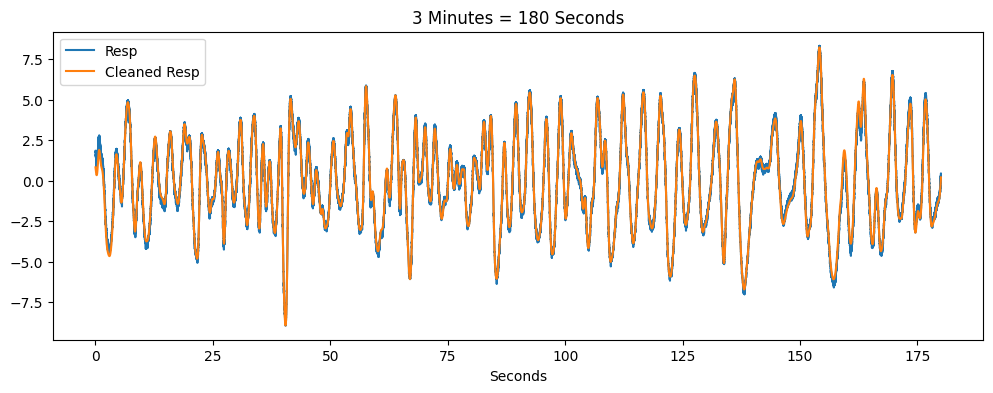

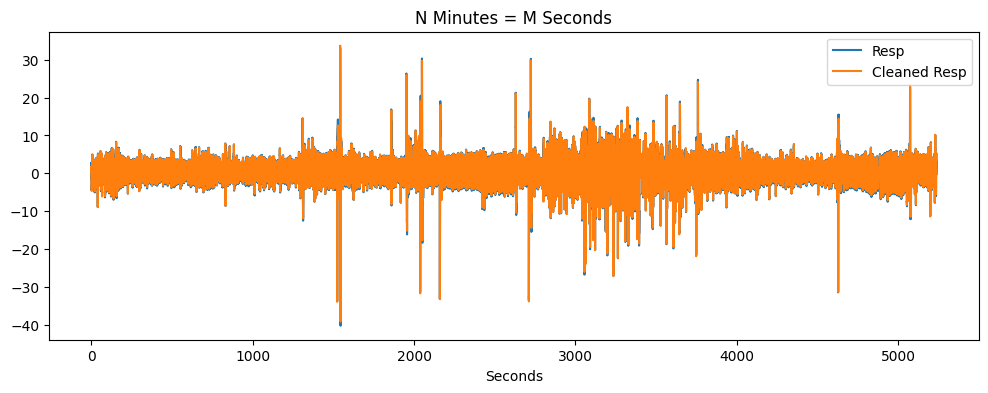

In [12]:
resp_df[filt_one_minute].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'1 Minute = {one_minute} Seconds')
resp_df[M_minutes_df].plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title=f'{m_minutes} Minutes = {M_seconds} Seconds')
resp_df.plot.line(x='Seconds', y=[health_measure_name, clean_col_name], figsize=(12, 4), title='N Minutes = M Seconds')

## Get Segments

In [13]:
segments_df, segments_groupby_df = DataProcessing.get_segments_by_duration(resp_df, window_size_sec=one_minute)
segments_df

,Resp,Milliseconds,Seconds,Time,Cleaned Resp,window_id,window_start_seconds,window_end_seconds
0,1.832581,0.00,0.00,0 days 00:00:00,0.826737,1,60,120
1,1.835632,1.43,0.00,0 days 00:00:00,0.823691,1,60,120
2,1.856995,2.86,0.00,0 days 00:00:00,0.820619,1,60,120
3,1.829529,4.29,0.00,0 days 00:00:00,0.817520,1,60,120
4,1.817322,5.71,0.01,0 days 00:00:00.010000,0.814394,1,60,120
...,...,...,...,...,...,...,...,...
3666595,0.813293,5237992.86,5237.99,0 days 01:27:17.990000,-0.001080,88,5280,5340
3666596,0.816345,5237994.29,5237.99,0 days 01:27:17.990000,-0.000927,88,5280,5340
3666597,0.804138,5237995.71,5238.00,0 days 01:27:18,-0.000788,88,5280,5340
3666598,0.834656,5237997.14,5238.00,0 days 01:27:18,-0.000663,88,5280,5340


In [14]:
window_ids = segments_df.loc[:, 'window_id'].unique()
window_ids

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88])

In [20]:
def filt_df(df, col_name, entry_value):
    filt_df = (df[col_name] == entry_value)
    df_with_filt = segments_df[filt_df]
    return df_with_filt

In [24]:
def get_stats(df, col_name):
    return {
        'Min': df[col_name].min(),
        'Max': df[col_name].max(),
        'Range': df[col_name].max() - df[col_name].min(),
        'Mean': df[col_name].mean(),
        'Median': df[col_name].median(),
        'Std': df[col_name].std()
    }

In [36]:
def get_plot_per_window(window_df, window_id):
        ax = window_df.plot.line(
            x='Seconds',
            y=[health_measure_name, clean_col_name],
            figsize=(12, 4),
            title=f'{window_id} Minute = {window_id*60} Seconds'
        )

        fig = ax.figure
        display(fig)
        plt.close(fig)   # <-- prevents the notebook from auto-rendering it again

{'Min': np.float64(-8.930843433296012),
 'Max': np.float64(5.833824420107683),
 'Range': np.float64(14.764667853403694),
 'Mean': np.float64(-0.023397456079465976),
 'Median': np.float64(-0.06981613430880895),
 'Std': np.float64(2.430730968598967)}

{'RSP_Peaks': array([ 3114,  4825,  6681,  8894, 11157, 13273, 15860, 18263, 19852,
        21618, 23650, 24977, 25968, 27593, 29080, 31710, 32906, 35468,
        38016]),
 'RSP_Troughs': array([ 2079,  3875,  5900,  7603, 10275, 12272, 15155, 17052, 19148,
        20636, 22600, 24410, 25442, 26738, 28325, 31074, 32429, 34284,
        36533]),
 'sampling_rate': 700}

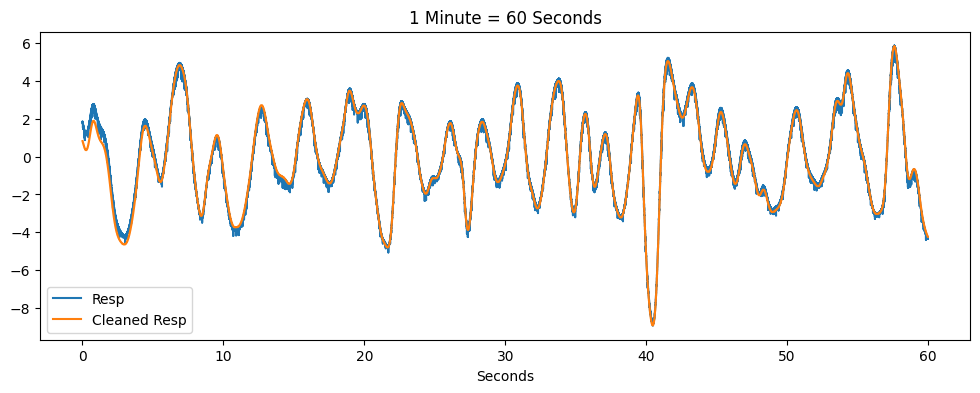

{'Min': np.float64(-6.068782044344294),
 'Max': np.float64(5.46140441024806),
 'Range': np.float64(11.530186454592354),
 'Mean': np.float64(-0.025226364097697202),
 'Median': np.float64(0.0060274372224425055),
 'Std': np.float64(2.6550326625088694)}

{'RSP_Peaks': array([ 2710,  3910,  5732,  7128,  8583, 10869, 16921, 18949, 20676,
        22724, 25207, 27319, 28926, 32836, 36637, 39670]),
 'RSP_Troughs': array([ 1843,  3376,  4868,  6249,  7926,  9610, 13573, 17782, 19686,
        21549, 23976, 26093, 28093, 31456, 34789, 38156]),
 'sampling_rate': 700}

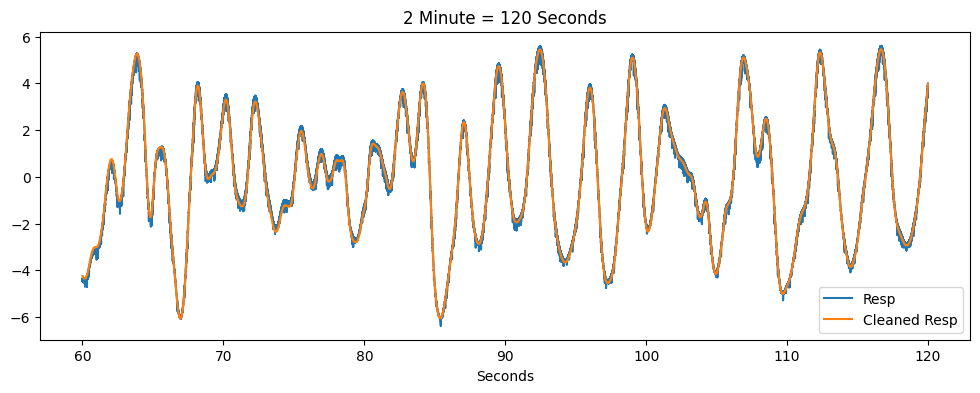

{'Min': np.float64(-6.707616173788099),
 'Max': np.float64(8.232974085626818),
 'Range': np.float64(14.940590259414918),
 'Mean': np.float64(-0.02177381565521122),
 'Median': np.float64(-0.47415757965094996),
 'Std': np.float64(3.2558310192617075)}

{'RSP_Peaks': array([ 3009,  5307,  8504, 11258, 17312, 21118, 23898, 27604, 30518,
        34782, 37444, 39718]),
 'RSP_Troughs': array([ 1663,  3987,  6524,  9656, 12676, 18511, 22141, 25999, 28565,
        33063, 36070, 38200]),
 'sampling_rate': 700}

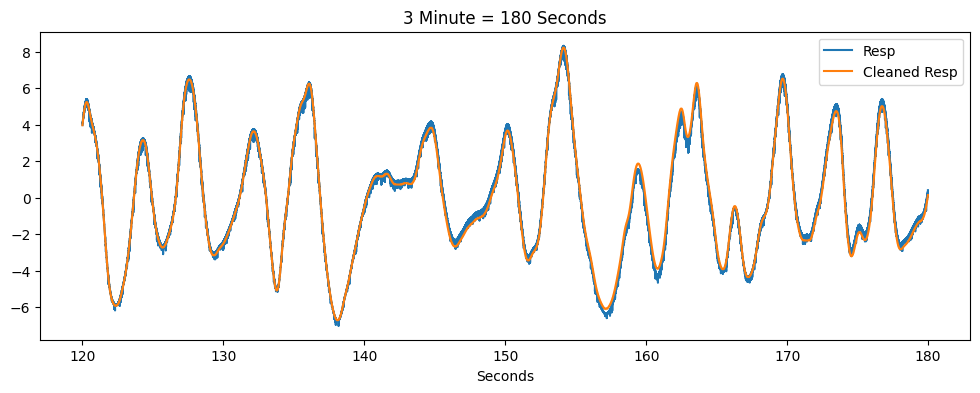

In [55]:
for window_id in window_ids:
    # Filt by window_id (which corresponds to certain timeframe)
    window_df = filt_df(segments_df, 'window_id', window_id)

    # Get stats per window
    window_stats = get_stats(window_df, col_name='Cleaned Resp')

    # Get inhalation (troughs) and exhalations (peaks)
    window_peak_signal_df, window_info = nk.rsp_peaks(window_df['Cleaned Resp'], respiration_frequency_sampling_rate)

    # Plot Window DF + Stats
    if window_id <= 3:
        display(window_stats)
        display(window_info)
        get_plot_per_window(window_df, window_id)
        print("="*24)

    # updated_window_df = pd.concat([window_df, window_peak_signal_df], axis=1)
